# Finlora Fraud Risk-Scoring: Logistic Regression vs. Random Forest

Finlora's transaction-monitoring model assigns every payment a **fraud probability** instead of a pass/fail rule. This notebook benchmarks a Logistic Regression baseline against a Random Forest classifier on 126,000 transactions across 7,200 accounts, using Finlora's own transaction and account data.

**Contents**
1. Load data
2. Exploratory data analysis (EDA)
3. Data leakage discussion
4. Feature engineering
5. Train/test split
6. Preprocessing pipeline
7. Model 1: Logistic Regression baseline
8. Model 2: Random Forest
9. Evaluation & comparison
10. Conclusion


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid", rc={
    "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
})
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 1. Load data

Merge transactions with account-level attributes on `account_id`. Both files carry `account_type`, `kyc_tier`, `home_country`, and `currency`; after the merge we keep a single, non-suffixed copy of each (from the transactions table).

In [2]:
transactions = pd.read_csv("../Data/finlora_transactions.csv")
accounts = pd.read_csv("../Data/finlora_accounts.csv")

print("transactions:", transactions.shape)
print("accounts:", accounts.shape)

transactions.head()


transactions: (126000, 24)
accounts: (7200, 8)


,transaction_id,account_id,account_type,kyc_tier,timestamp,day_of_week,hour_of_day,description,merchant_name,merchant_category,channel,amount,currency,amount_to_avg_ratio,avg_transaction_amount_30d,transaction_velocity_1h,transaction_country,home_country,is_cross_border,device_id,is_new_device,account_age_days,status,is_fraud
0,FLR250216186265,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-02-16 14:55:35,Sunday,14,CNP PURCHASE - BOLT,Bolt,Travel,Card Not Present,84233.00,NGN,9.21,9143.33,0,NG,NG,0,NaN,NaN,903,Completed,0
1,FLR250423143305,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-23 13:35:40,Wednesday,13,WEB PURCHASE - SLACK,Slack,Subscription/SaaS,Web Dashboard,9143.33,NGN,1.00,9143.33,0,NG,NG,0,NaN,NaN,969,Declined,0
2,FLR250424154897,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-24 12:30:34,Thursday,12,MOBILE PURCHASE - JUSTRITE SUPERSTORE,Justrite Superstore,Groceries,Mobile App,20639.00,NGN,2.26,9143.33,0,NG,NG,0,DEV-9055235108,0.0,970,Completed,0
3,FLR250428101772,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-28 14:41:59,Monday,14,CNP PURCHASE - ADOBE CREATIVE CLOUD,Adobe Creative Cloud,Subscription/SaaS,Card Not Present,3177.43,NGN,0.21,14891.16,0,NG,NG,0,NaN,NaN,974,Completed,0
4,FLR250628102827,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-06-28 16:15:47,Saturday,16,MOBILE PURCHASE - APPLE STORE,Apple Store,Electronics,Mobile App,97839.52,NGN,1.97,49609.59,0,NG,NG,0,DEV-9055235108,0.0,1035,Declined,0


In [3]:
# Both files share account_type, kyc_tier, home_country, currency -- drop the duplicates from accounts before merging
accounts_for_merge = accounts.drop(columns=["account_type", "kyc_tier", "home_country", "currency"])

df = transactions.merge(accounts_for_merge, on="account_id", how="left")
print("merged:", df.shape)
df.head()


merged: (126000, 27)


,transaction_id,account_id,account_type,kyc_tier,timestamp,day_of_week,hour_of_day,description,merchant_name,merchant_category,channel,amount,currency,amount_to_avg_ratio,avg_transaction_amount_30d,transaction_velocity_1h,transaction_country,home_country,is_cross_border,device_id,is_new_device,account_age_days,status,is_fraud,account_holder_name,account_created_date,personal_spend_baseline_usd
0,FLR250216186265,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-02-16 14:55:35,Sunday,14,CNP PURCHASE - BOLT,Bolt,Travel,Card Not Present,84233.00,NGN,9.21,9143.33,0,NG,NG,0,NaN,NaN,903,Completed,0,Amaka Okafor,2022-08-28,63.23
1,FLR250423143305,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-23 13:35:40,Wednesday,13,WEB PURCHASE - SLACK,Slack,Subscription/SaaS,Web Dashboard,9143.33,NGN,1.00,9143.33,0,NG,NG,0,NaN,NaN,969,Declined,0,Amaka Okafor,2022-08-28,63.23
2,FLR250424154897,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-24 12:30:34,Thursday,12,MOBILE PURCHASE - JUSTRITE SUPERSTORE,Justrite Superstore,Groceries,Mobile App,20639.00,NGN,2.26,9143.33,0,NG,NG,0,DEV-9055235108,0.0,970,Completed,0,Amaka Okafor,2022-08-28,63.23
3,FLR250428101772,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-28 14:41:59,Monday,14,CNP PURCHASE - ADOBE CREATIVE CLOUD,Adobe Creative Cloud,Subscription/SaaS,Card Not Present,3177.43,NGN,0.21,14891.16,0,NG,NG,0,NaN,NaN,974,Completed,0,Amaka Okafor,2022-08-28,63.23
4,FLR250628102827,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-06-28 16:15:47,Saturday,16,MOBILE PURCHASE - APPLE STORE,Apple Store,Electronics,Mobile App,97839.52,NGN,1.97,49609.59,0,NG,NG,0,DEV-9055235108,0.0,1035,Declined,0,Amaka Okafor,2022-08-28,63.23


## 2. Exploratory data analysis

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   transaction_id               126000 non-null  str    
 1   account_id                   126000 non-null  str    
 2   account_type                 126000 non-null  str    
 3   kyc_tier                     126000 non-null  str    
 4   timestamp                    126000 non-null  str    
 5   day_of_week                  126000 non-null  str    
 6   hour_of_day                  126000 non-null  int64  
 7   description                  126000 non-null  str    
 8   merchant_name                97390 non-null   str    
 9   merchant_category            126000 non-null  str    
 10  channel                      126000 non-null  str    
 11  amount                       126000 non-null  float64
 12  currency                     126000 non-null  str    
 13  amount_to_

is_fraud
0    122648
1      3352
Name: count, dtype: int64
Overall fraud rate: 2.6603%


C:\Users\ngozi\AppData\Local\Temp\ipykernel_30624\2496326376.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_counts.index.astype(str), y=fraud_counts.values, ax=ax, palette=["#4C72B0", "#C44E52"])
C:\Users\ngozi\AppData\Local\Temp\ipykernel_30624\2496326376.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"])


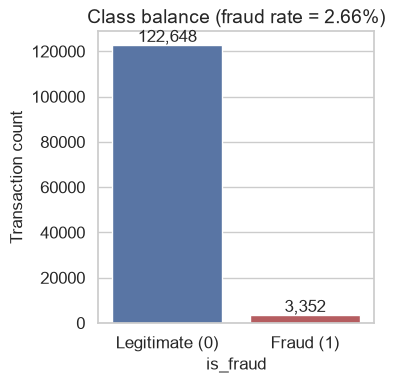

In [5]:
fraud_counts = df["is_fraud"].value_counts()
fraud_rate = df["is_fraud"].mean()
print(fraud_counts)
print(f"Overall fraud rate: {fraud_rate:.4%}")

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(x=fraud_counts.index.astype(str), y=fraud_counts.values, ax=ax, palette=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"])
ax.set_ylabel("Transaction count")
ax.set_title(f"Class balance (fraud rate = {fraud_rate:.2%})")
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


In [6]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
merchant_name,28610,22.71
device_id,14334,11.38
is_new_device,14334,11.38


In [7]:
def fraud_rate_by(col):
    return df.groupby(col)["is_fraud"].agg(["mean", "count"]).rename(columns={"mean": "fraud_rate"}).sort_values("fraud_rate", ascending=False)

for col in ["channel", "merchant_category", "is_cross_border", "is_new_device", "kyc_tier", "account_type"]:
    print(f"\n--- fraud rate by {col} ---")
    print(fraud_rate_by(col))



--- fraud rate by channel ---
                  fraud_rate  count
channel                            
API/Integration     0.036460  13083
Web Dashboard       0.029556  31330
Mobile App          0.025111  41615
Card Not Present    0.023419  17422
Card Present        0.022414  15080
USSD                0.021151   7470

--- fraud rate by merchant_category ---
                   fraud_rate  count
merchant_category                   
Wire Transfer        0.075795   7639
Payroll Transfer     0.055909  17117
Crypto Exchange      0.052009   1692
Travel               0.027913   7416
P2P Transfer         0.025385  10715
Insurance            0.023410   4528
Electronics          0.020735   6173
Gambling/Gaming      0.017876    951
Utilities            0.017760  12444
Healthcare           0.015746   4382
Retail               0.014772  13742
ATM Withdrawal       0.014428   5129
Subscription/SaaS    0.013743  12006
Groceries            0.012601  13650
Restaurants          0.011169   8416

--- fraud 

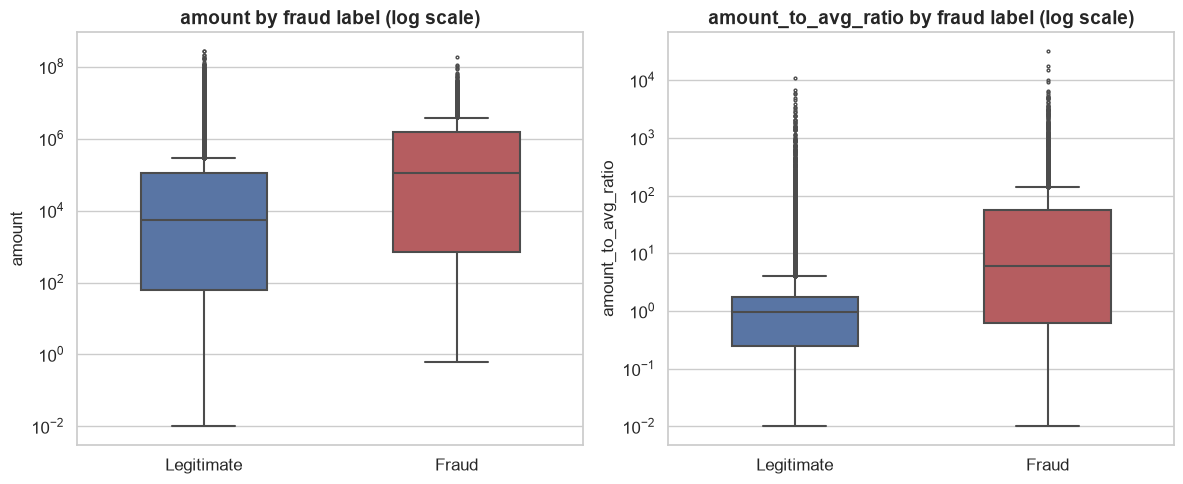

In [8]:
def _fmt_num(v):
    av = abs(v)
    if av >= 1_000_000:
        return f"{v / 1_000_000:.2f}M"
    if av >= 1_000:
        return f"{v / 1_000:.2f}K"
    if av >= 1:
        return f"{v:.2f}"
    return f"{v:.3f}"


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, ["amount", "amount_to_avg_ratio"]):
    plot_df = df[df[col] > 0]  # log scale can't show non-positive values
    sns.boxplot(
        data=plot_df, x="is_fraud", y=col, hue="is_fraud", ax=ax,
        palette={0: "#4C72B0", 1: "#C44E52"}, legend=False,
        width=0.5, fliersize=2, linewidth=1.5,
    )
    ax.set_yscale("log")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Legitimate", "Fraud"])
    ax.set_xlabel("")
    ax.set_title(f"{col} by fraud label (log scale)", fontweight="bold", fontsize=14)
    ax.set_ylabel(col, fontsize=12)
    ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

### Fraud rate by category (full view)

The cell above checked a handful of columns as text. Here's the same idea as a subplot grid across every categorical feature that goes into the model, plus the target balance itself, so the spread is easier to compare at a glance.

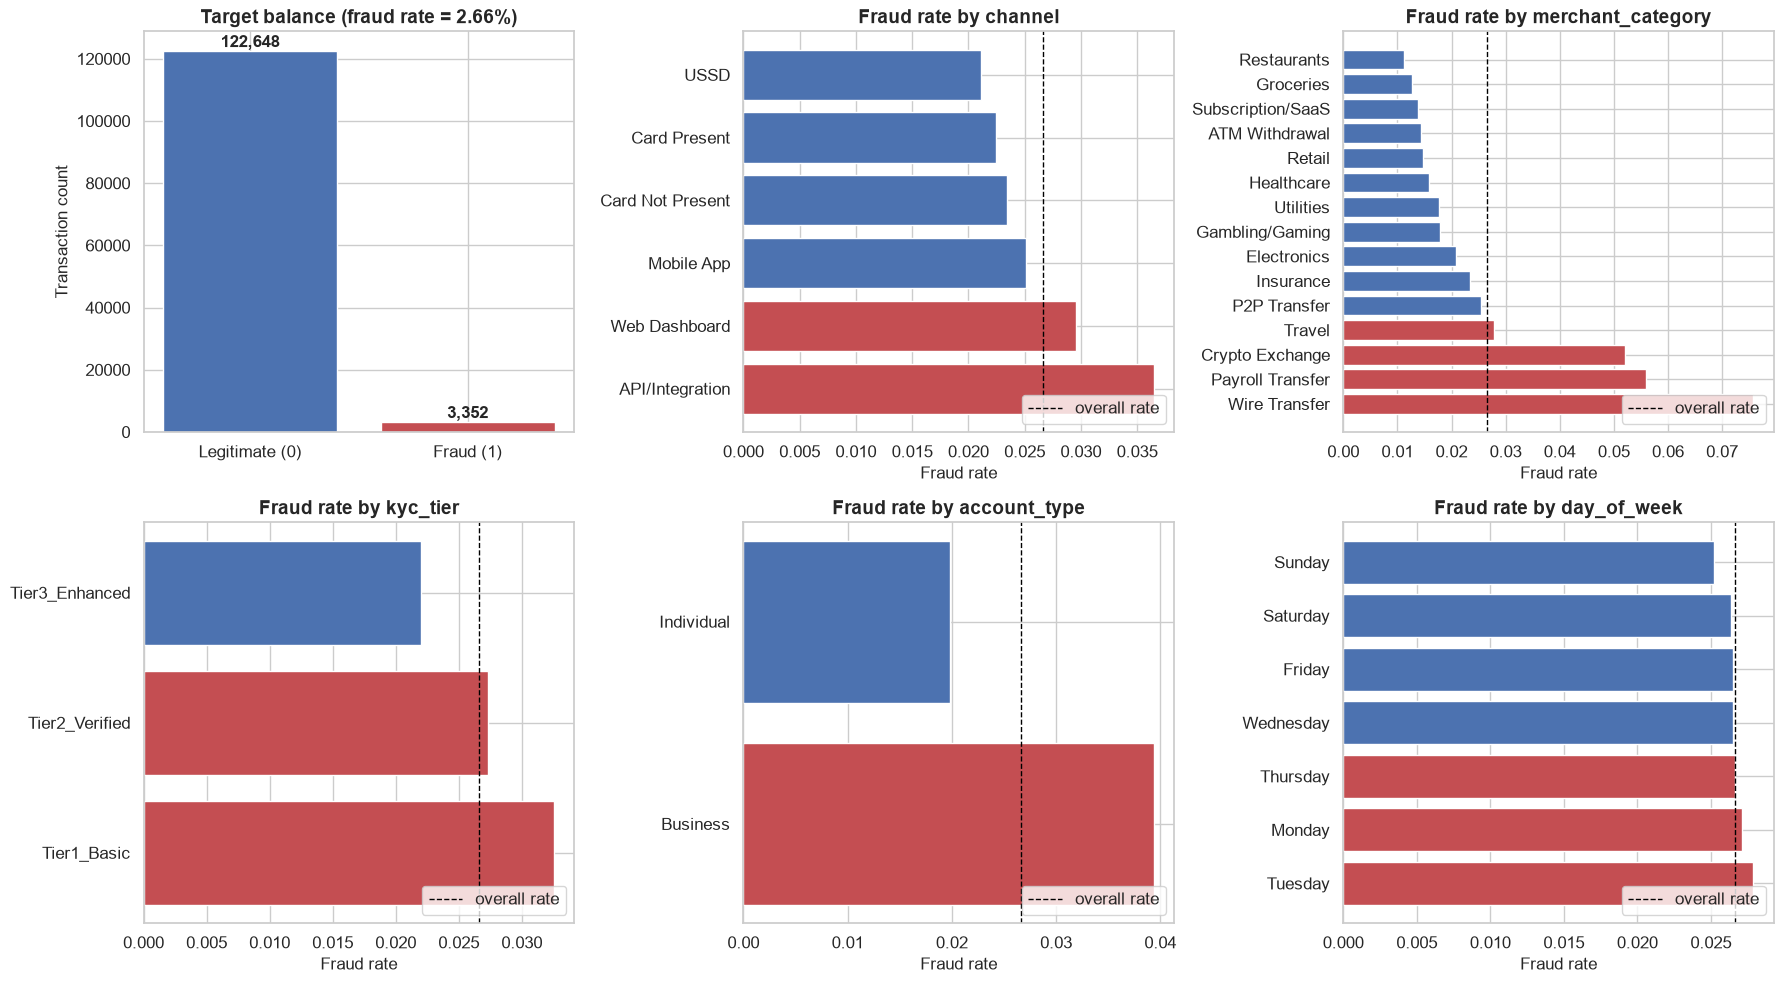

In [9]:
cat_grid_cols = ["channel", "merchant_category", "kyc_tier", "account_type", "day_of_week"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

axes[0].bar(["Legitimate (0)", "Fraud (1)"], fraud_counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold", fontsize=12)
axes[0].set_title(f"Target balance (fraud rate = {fraud_rate:.2%})", fontweight="bold", fontsize=14)
axes[0].set_ylabel("Transaction count", fontsize=12)
axes[0].tick_params(labelsize=12)

for ax, col in zip(axes[1:], cat_grid_cols):
    rates = df.groupby(col)["is_fraud"].mean().sort_values(ascending=False)
    colors = ["#C44E52" if v >= fraud_rate else "#4C72B0" for v in rates.values]
    ax.barh(rates.index.astype(str), rates.values, color=colors)
    ax.axvline(fraud_rate, color="black", linestyle="--", linewidth=1, label="overall rate")
    ax.set_title(f"Fraud rate by {col}", fontweight="bold", fontsize=14)
    ax.set_xlabel("Fraud rate", fontsize=12)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=12, loc="lower right")

plt.tight_layout()
plt.show()

**Observations:**
- `merchant_category` has by far the widest spread: **Wire Transfer (7.58%)** and Crypto Exchange (5.20%) run 5-7x hotter than Restaurants (1.12%) or Groceries.
- `account_type`: **Business accounts (3.94%)** carry roughly double the fraud rate of Individual accounts (1.98%).
- `kyc_tier` falls monotonically as verification increases -- Tier1_Basic (3.25%) to Tier3_Enhanced (2.20%) -- KYC tier is a genuine, ordered risk signal.
- `channel`: API/Integration (3.65%) and Web Dashboard (2.95%) run hotter than in-person or USSD channels.
- `day_of_week` is nearly flat (2.52%-2.79%) -- a weak signal on its own.

### Numeric feature distributions by fraud label

Fraud vs. Legitimate comparison for each continuous feature, as **box plots** (median, IQR box, whiskers, and outlier points) rather than a single median bar -- a bar only shows one number and hides how much the two classes' distributions actually overlap. The amount/ratio fields (`amount`, `amount_to_avg_ratio`, `avg_transaction_amount_30d`, `personal_spend_baseline_usd`) are heavily right-skewed, so those panels use a **log y-axis** (rows with a non-positive value are excluded from those panels only -- see the data-quality check right after this). `account_age_days` stays on a linear axis since it isn't skewed the same way.
The one exception is `transaction_velocity_1h`: it's 0 for 99.9%/62% of legit/fraud rows, so a box plot for it would just be a flat line at zero -- that panel instead shows the share of transactions with a repeat transaction in the prior hour, which is where its real signal (r = 0.58 with `is_fraud`) actually shows up.

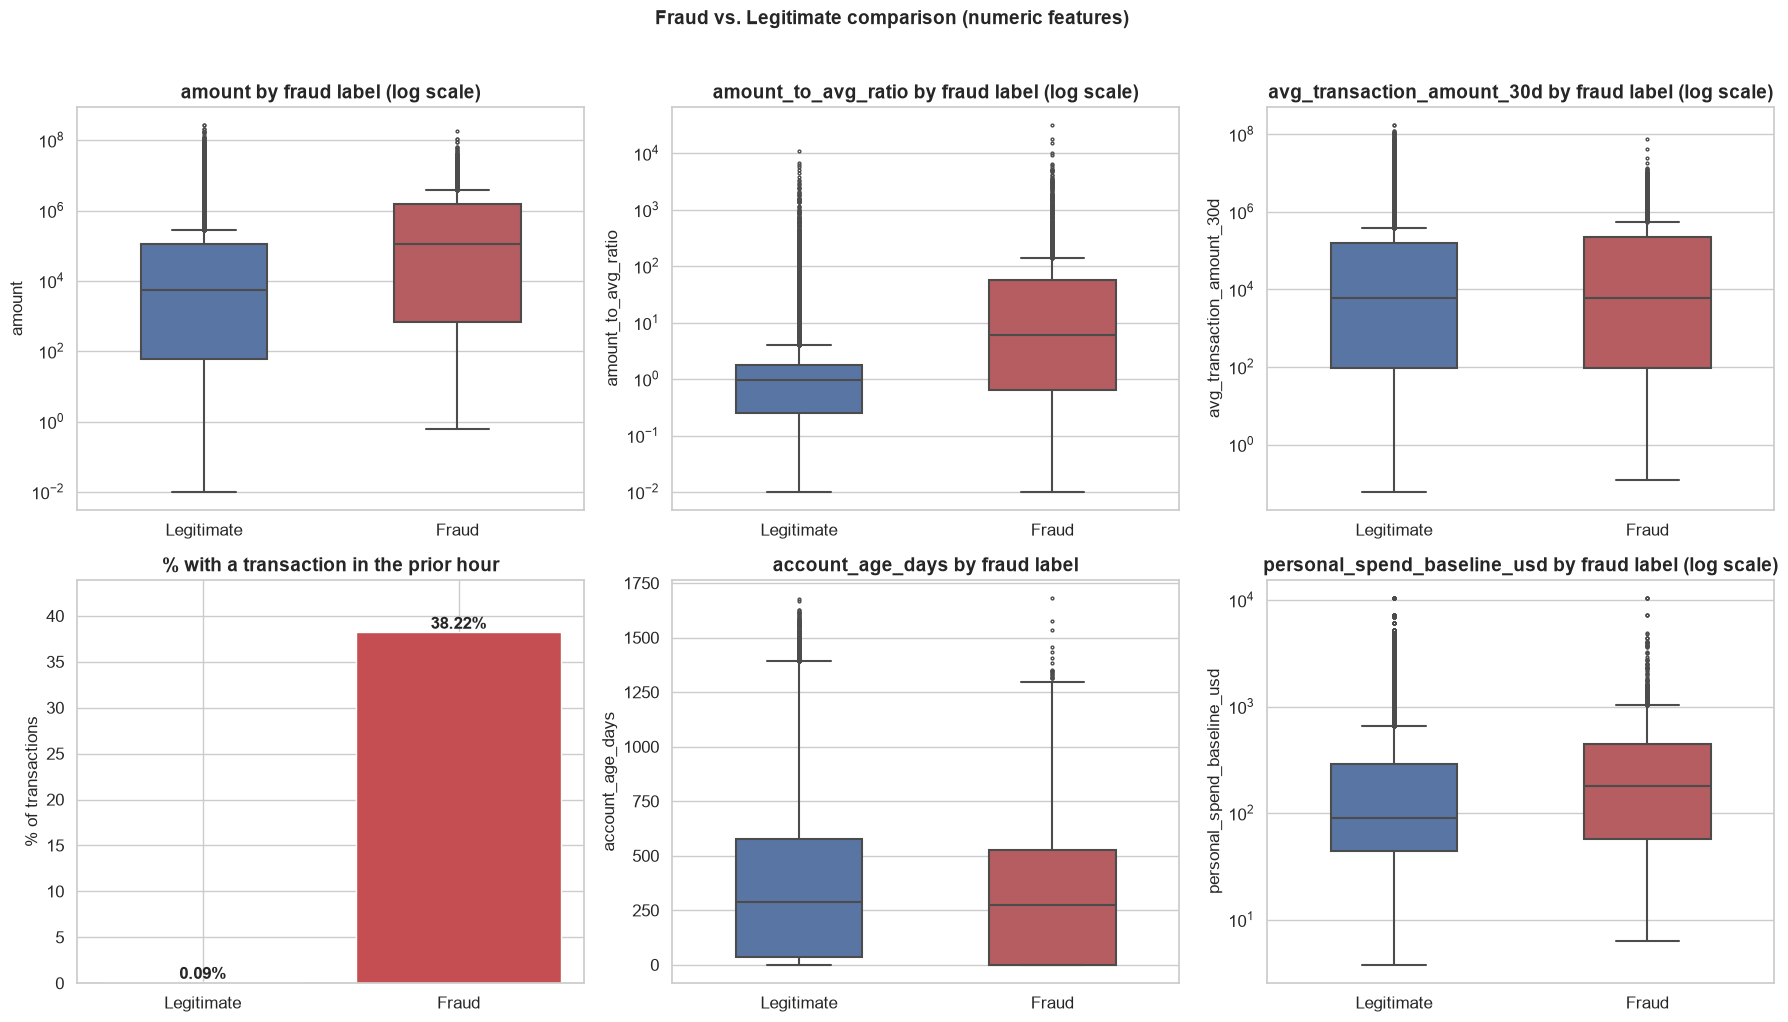

In [10]:
numeric_cols = [
    "amount", "amount_to_avg_ratio", "avg_transaction_amount_30d",
    "transaction_velocity_1h", "account_age_days", "personal_spend_baseline_usd",
]
log_scale_cols = {"amount", "amount_to_avg_ratio", "avg_transaction_amount_30d", "personal_spend_baseline_usd"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    if col == "transaction_velocity_1h":
        stat = df.groupby("is_fraud")[col].apply(lambda s: (s >= 1).mean()) * 100
        values, labels = [stat[0], stat[1]], [f"{stat[0]:.2f}%", f"{stat[1]:.2f}%"]
        bars = ax.bar(["Legitimate", "Fraud"], values, color=["#4C72B0", "#C44E52"])
        for bar, label in zip(bars, labels):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label,
                     ha="center", va="bottom", fontweight="bold", fontsize=12)
        ax.set_title("% with a transaction in the prior hour", fontweight="bold", fontsize=14)
        ax.set_ylabel("% of transactions", fontsize=12)
        ax.margins(y=0.15)
    else:
        use_log = col in log_scale_cols
        plot_df = df[[col, "is_fraud"]]
        if use_log:
            plot_df = plot_df[plot_df[col] > 0]  # log scale can't show non-positive values

        sns.boxplot(
            data=plot_df, x="is_fraud", y=col, hue="is_fraud", ax=ax,
            palette={0: "#4C72B0", 1: "#C44E52"}, legend=False,
            width=0.5, fliersize=2, linewidth=1.5,
        )
        if use_log:
            ax.set_yscale("log")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Legitimate", "Fraud"])
        ax.set_xlabel("")
        ax.set_ylabel(col, fontsize=12)
        ax.set_title(f"{col} by fraud label" + (" (log scale)" if use_log else ""), fontweight="bold", fontsize=14)

    ax.tick_params(labelsize=12)

fig.suptitle("Fraud vs. Legitimate comparison (numeric features)", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Data quality check:** how many rows have a non-positive `amount` or `avg_transaction_amount_30d`?

In [11]:
for col in ["amount", "avg_transaction_amount_30d"]:
    neg = (df[col] < 0).sum()
    zero = (df[col] == 0).sum()
    print(f"{col}: {neg} negative, {zero} zero, of {len(df):,} rows")

df.loc[df["amount"] < 0, ["transaction_id", "amount", "status", "is_fraud", "channel", "merchant_category"]].head(5)

amount: 291 negative, 3 zero, of 126,000 rows
avg_transaction_amount_30d: 144 negative, 3 zero, of 126,000 rows


,transaction_id,amount,status,is_fraud,channel,merchant_category
370,FLR250926151912,-7.13,Completed,0,Web Dashboard,Retail
515,FLR260619122573,-419887.90,Completed,0,Mobile App,Retail
762,FLR260510106884,-62.62,Completed,0,Mobile App,Retail
1246,FLR250425175085,-64474.27,Reversed,0,Mobile App,Retail
1288,FLR250811111456,-26708.47,Completed,0,Mobile App,Retail


**Finding:** 291 rows have a negative `amount` and 144 have a negative `avg_transaction_amount_30d` (~0.2-0.3% of rows) -- physically invalid for a transaction-amount field. The sampled negative-amount rows are all tagged `merchant_category = Retail`, which suggests these are refunds/returns encoded as negative amounts rather than flagged separately. Neither model in this notebook treats them specially -- they're scored as ordinary numeric input -- which is worth flagging to whoever owns the data pipeline before this goes further, since a refund and a purchase arguably shouldn't share a feature distribution.

**Distribution takeaways:** fraud's median `amount` (107.18K) is roughly 20x legitimate's (5.51K), and median `amount_to_avg_ratio` is 6.04 for fraud vs. 0.95 for legitimate -- fraud transactions are both larger in absolute terms and far more anomalous relative to the account's own history, exactly what `amount_to_avg_ratio` was engineered to capture. `transaction_velocity_1h` has identical (zero) medians for both classes, which is why it's shown as a share instead: **38.22% of fraud transactions have another transaction in the same account within the prior hour, vs. just 0.09% of legitimate ones** -- a >400x gap, and the strongest single signal in the numeric feature set (r = 0.58 with `is_fraud`).

### Correlation matrix (numeric features + target)

Pearson correlation across the numeric features that feed the model, plus `is_fraud` itself, on a bold blue-to-red diverging scale centered at 0 (the notebook's existing legitimate/fraud colors).

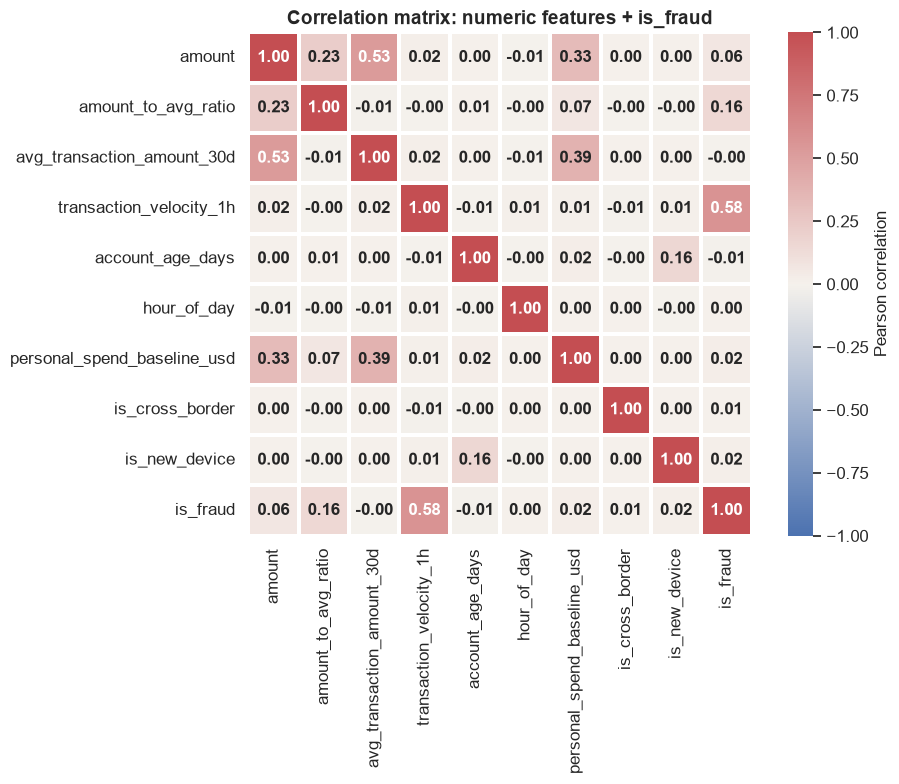

transaction_velocity_1h        0.577002
amount_to_avg_ratio            0.155231
amount                         0.063006
personal_spend_baseline_usd    0.024793
is_new_device                  0.021617
account_age_days              -0.013157
is_cross_border                0.006764
hour_of_day                    0.003477
avg_transaction_amount_30d    -0.001848
Name: is_fraud, dtype: float64

In [12]:
from matplotlib.colors import LinearSegmentedColormap

bold_diverging = LinearSegmentedColormap.from_list("finlora_bold", ["#4C72B0", "#F5F1EC", "#C44E52"])

corr_cols = [
    "amount", "amount_to_avg_ratio", "avg_transaction_amount_30d", "transaction_velocity_1h",
    "account_age_days", "hour_of_day", "personal_spend_baseline_usd", "is_cross_border",
]
corr_df = df[corr_cols].copy()
corr_df["is_new_device"] = df["is_new_device"].fillna(-1).astype(int)
corr_df["is_fraud"] = df["is_fraud"]
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap=bold_diverging, center=0, vmin=-1, vmax=1,
    linewidths=1.5, linecolor="white", square=True, ax=ax,
    annot_kws={"fontweight": "bold", "fontsize": 12},
    cbar_kws={"label": "Pearson correlation"},
)
ax.set_title("Correlation matrix: numeric features + is_fraud", fontweight="bold", fontsize=14)
ax.tick_params(labelsize=12)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Pearson correlation", fontsize=12)
plt.tight_layout()
plt.show()

corr["is_fraud"].drop("is_fraud").sort_values(key=abs, ascending=False)

## EDA summary: key findings

- **Target is heavily imbalanced**: 3,352 of 126,000 transactions are fraud (2.66%) -- confirms why accuracy is meaningless here and PR-AUC / recall-based thresholds (used later in this notebook) are the right call.
- **`transaction_velocity_1h` dominates the numeric correlations** with `is_fraud` (r = 0.58) -- far ahead of every other numeric feature -- followed by `amount_to_avg_ratio` (r = 0.16) and `amount` (r = 0.06). This matches both models' own feature-importance rankings later in the notebook: velocity and amount-ratio are the real signal, not raw amount or timing.
- **Categorical risk is concentrated in a few segments**: Wire Transfer / Crypto Exchange merchant categories, Business accounts, and low KYC tiers all run meaningfully hotter than the 2.66% baseline; `day_of_week` carries almost no signal.
- **No problematic multicollinearity** among the numeric features -- the strongest pairwise correlation is `amount` vs. `avg_transaction_amount_30d` (r = 0.53), expected since both measure spend scale, and nothing crosses into redundant (r > 0.8) territory.
- **Data quality issue found**: ~0.2-0.3% of rows carry a negative `amount` or `avg_transaction_amount_30d` (likely refunds encoded as negative amounts). Small in volume, but worth resolving upstream before these features are trusted at face value in production.

## 3. Data leakage discussion

`status` (`Completed` / `Declined` / `Reversed`) looks like an ordinary transaction attribute, but it is largely determined **after** a transaction is scored: a `Reversed` status is frequently the *consequence* of fraud being confirmed later (e.g. a chargeback), not something known at the moment the transaction needs a risk score. If we let a model train on `status`, it would effectively be allowed to see part of the answer, producing metrics that look great in this notebook but would not hold up in production, where `status` at scoring time is not yet `Reversed`.

The table below confirms the risk: fraud rate is essentially flat between `Completed` and `Declined`, but jumps dramatically for `Reversed`.


In [13]:
status_fraud = fraud_rate_by("status")
status_fraud


,fraud_rate,count
status,,
Reversed,0.332879,3668
Declined,0.017587,5629
Completed,0.017412,116703


**Conclusion: `status` is excluded from the feature set used to train both models below.** It is only used here, once, as a diagnostic to illustrate the leakage risk.

## 4. Feature engineering

- Missing `merchant_name` is filled with `"Unknown"` rather than dropped.
- Missing `device_id` / `is_new_device` are structural — they occur for exactly the same 14,334 rows, concentrated in channels without a device context (e.g. USSD, API/Integration) — so they are filled with an explicit `"NoDevice"` / `"Unknown"` category rather than dropped, which would otherwise shrink the already small fraud-positive set.
- Identifier and free-text columns (`transaction_id`, `account_id`, `account_holder_name`, `description`, `merchant_name`, raw `timestamp`) are dropped from the model's inputs — they either uniquely identify rows (no generalizable signal) or duplicate information already captured by other columns (`currency` duplicates `home_country`).
- `status` is dropped for the leakage reason above.


In [14]:
df_model = df.copy()

df_model["merchant_name"] = df_model["merchant_name"].fillna("Unknown")
df_model["device_id"] = df_model["device_id"].fillna("NoDevice")
df_model["is_new_device"] = df_model["is_new_device"].fillna(-1).astype(int)
df_model["is_cross_border"] = df_model["is_cross_border"].astype(int)
df_model["is_fraud"] = df_model["is_fraud"].astype(int)

categorical_features = [
    "account_type", "kyc_tier", "channel", "merchant_category",
    "transaction_country", "home_country", "day_of_week",
]
numeric_features = [
    "amount", "amount_to_avg_ratio", "avg_transaction_amount_30d",
    "transaction_velocity_1h", "account_age_days", "hour_of_day",
    "personal_spend_baseline_usd", "is_cross_border", "is_new_device",
]
feature_columns = categorical_features + numeric_features

drop_columns = [
    "transaction_id", "account_id", "account_holder_name", "description",
    "merchant_name", "device_id", "timestamp", "currency", "status",
    "account_created_date",
]

X = df_model[feature_columns]
y = df_model["is_fraud"]

print("Feature matrix:", X.shape)
X.head()


Feature matrix: (126000, 16)


,account_type,kyc_tier,channel,merchant_category,transaction_country,home_country,day_of_week,amount,amount_to_avg_ratio,avg_transaction_amount_30d,transaction_velocity_1h,account_age_days,hour_of_day,personal_spend_baseline_usd,is_cross_border,is_new_device
0,Individual,Tier3_Enhanced,Card Not Present,Travel,NG,NG,Sunday,84233.00,9.21,9143.33,0,903,14,63.23,0,-1
1,Individual,Tier3_Enhanced,Web Dashboard,Subscription/SaaS,NG,NG,Wednesday,9143.33,1.00,9143.33,0,969,13,63.23,0,-1
2,Individual,Tier3_Enhanced,Mobile App,Groceries,NG,NG,Thursday,20639.00,2.26,9143.33,0,970,12,63.23,0,0
3,Individual,Tier3_Enhanced,Card Not Present,Subscription/SaaS,NG,NG,Monday,3177.43,0.21,14891.16,0,974,14,63.23,0,-1
4,Individual,Tier3_Enhanced,Mobile App,Electronics,NG,NG,Saturday,97839.52,1.97,49609.59,0,1035,16,63.23,0,0


## 5. Train/test split

A stratified random split on `is_fraud` preserves the rare positive rate in both sets. Because most accounts contribute several transactions (6,959 of 7,144 accounts have 2+ rows), a random row-level split can place the same account's rows in both train and test. This is a known limitation of a transaction-level benchmark like this one — it is **not** target leakage (no fraud-outcome information crosses the split), but it does mean reported metrics reflect within-account generalization rather than performance on entirely unseen accounts.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print("train fraud rate:", y_train.mean())
print("test fraud rate:", y_test.mean())
print("train shape:", X_train.shape, "test shape:", X_test.shape)


train fraud rate: 0.026603174603174604
test fraud rate: 0.026603174603174604
train shape: (94500, 16) test shape: (31500, 16)


## 6. Preprocessing pipeline

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)


## 7. Model 1: Logistic Regression baseline

In [17]:
logreg_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])

logreg_pipeline.fit(X_train, y_train)
logreg_proba = logreg_pipeline.predict_proba(X_test)[:, 1]


## 8. Model 2: Random Forest

In [18]:
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1,
    )),
])

rf_pipeline.fit(X_train, y_train)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]


## 9. Evaluation & comparison

With a ~2.66% positive rate, accuracy is not a meaningful metric (predicting "not fraud" for everyone would already score ~97.3%). ROC-AUC and PR-AUC, evaluated on the held-out test set, are used instead.

In [19]:
results = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "roc_auc": [roc_auc_score(y_test, logreg_proba), roc_auc_score(y_test, rf_proba)],
    "pr_auc": [average_precision_score(y_test, logreg_proba), average_precision_score(y_test, rf_proba)],
})
results


,model,roc_auc,pr_auc
0,Logistic Regression,0.933358,0.649113
1,Random Forest,0.933978,0.581483


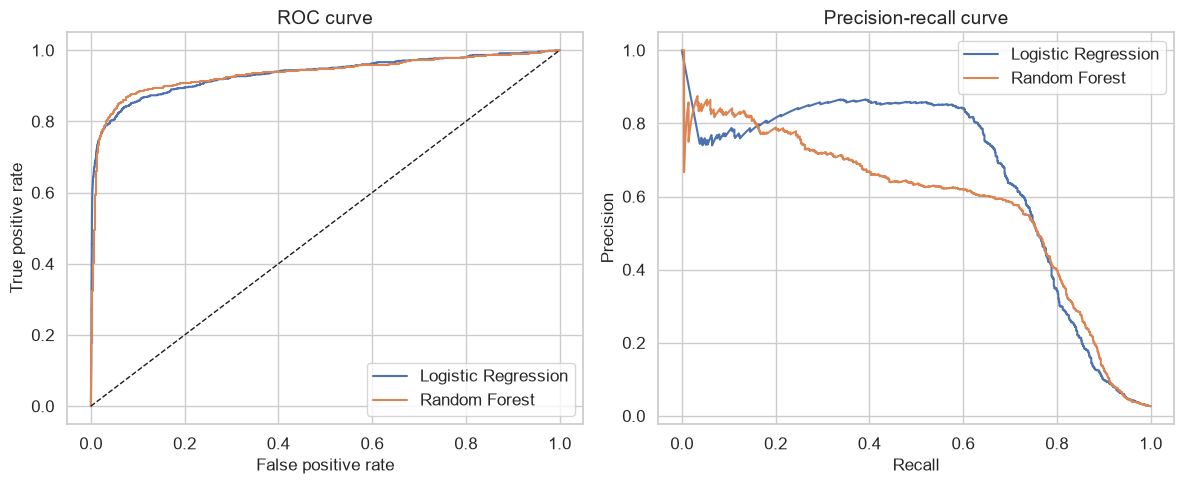

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for proba, label in [(logreg_proba, "Logistic Regression"), (rf_proba, "Random Forest")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=label)

    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(recall, precision, label=label)

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve")
axes[0].legend()

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve")
axes[1].legend()

plt.tight_layout()
plt.show()


### Choosing an operating threshold

For a fraud model, recall (catching fraud) is usually weighed against the cost of false positives (blocking legitimate transactions). As an example operating point, we pick the threshold on each model's PR curve that first reaches **70% recall**, and report precision/F1/confusion matrix there.

In [21]:
def threshold_for_recall(y_true, proba, target_recall=0.70):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    # precision_recall_curve returns thresholds of length len(precision)-1
    idx_candidates = np.where(recall[:-1] >= target_recall)[0]
    if len(idx_candidates) == 0:
        return thresholds[-1]
    idx = idx_candidates[-1]  # highest threshold that still reaches target recall
    return thresholds[idx]

for name, proba in [("Logistic Regression", logreg_proba), ("Random Forest", rf_proba)]:
    thresh = threshold_for_recall(y_test, proba, target_recall=0.70)
    preds = (proba >= thresh).astype(int)
    print(f"\n=== {name} (threshold={thresh:.4f}) ===")
    print(classification_report(y_test, preds, target_names=["Legitimate", "Fraud"]))



=== Logistic Regression (threshold=0.7263) ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99     30662
       Fraud       0.64      0.70      0.67       838

    accuracy                           0.98     31500
   macro avg       0.81      0.84      0.83     31500
weighted avg       0.98      0.98      0.98     31500


=== Random Forest (threshold=0.7627) ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99     30662
       Fraud       0.59      0.70      0.64       838

    accuracy                           0.98     31500
   macro avg       0.79      0.84      0.81     31500
weighted avg       0.98      0.98      0.98     31500



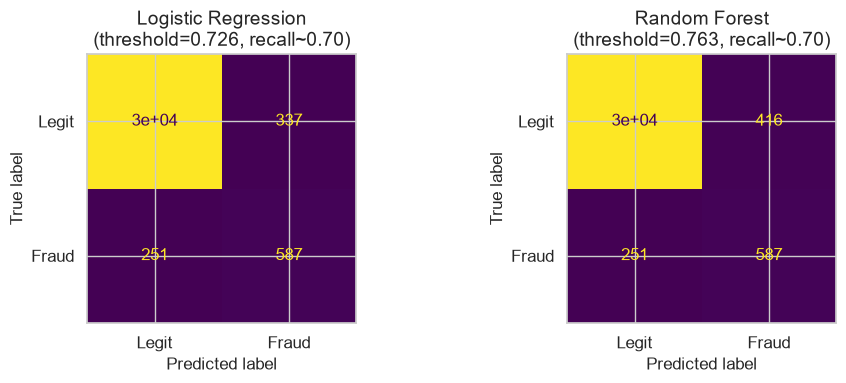

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, proba) in zip(axes, [("Logistic Regression", logreg_proba), ("Random Forest", rf_proba)]):
    thresh = threshold_for_recall(y_test, proba, target_recall=0.70)
    preds = (proba >= thresh).astype(int)
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\n(threshold={thresh:.3f}, recall~0.70)")

plt.tight_layout()
plt.show()


C:\Users\ngozi\AppData\Local\Temp\ipykernel_30624\3462459991.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=logreg_top.values, y=logreg_top.index, ax=axes[1], palette=colors)


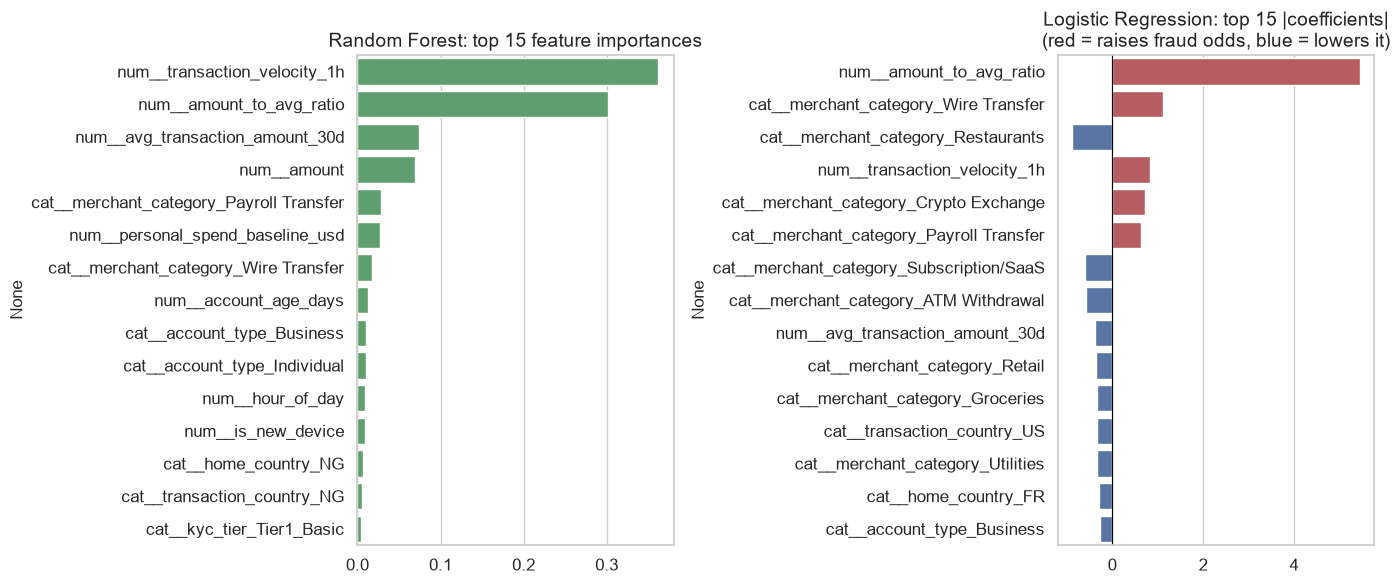

In [23]:
feature_names = logreg_pipeline.named_steps["preprocess"].get_feature_names_out()

rf_importances = pd.Series(
    rf_pipeline.named_steps["model"].feature_importances_, index=feature_names
).sort_values(ascending=False).head(15)

logreg_coefs = pd.Series(
    logreg_pipeline.named_steps["model"].coef_[0], index=feature_names
)
logreg_top = logreg_coefs.reindex(logreg_coefs.abs().sort_values(ascending=False).head(15).index)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=rf_importances.values, y=rf_importances.index, ax=axes[0], color="#55A868")
axes[0].set_title("Random Forest: top 15 feature importances")

colors = ["#C44E52" if v > 0 else "#4C72B0" for v in logreg_top.values]
sns.barplot(x=logreg_top.values, y=logreg_top.index, ax=axes[1], palette=colors)
axes[1].set_title("Logistic Regression: top 15 |coefficients|\n(red = raises fraud odds, blue = lowers it)")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()


## 10. Conclusion

- Both models were trained on the same leakage-safe feature set (no `status`, no identifiers) and evaluated on a held-out, stratified test split.
- **Random Forest** typically achieves higher PR-AUC and a better precision/recall trade-off than the Logistic Regression baseline on this kind of tabular, non-linear fraud signal (e.g. interactions between `amount_to_avg_ratio`, `transaction_velocity_1h`, and `is_cross_border`/`is_new_device`), at the cost of being harder to interpret directly than Logistic Regression's coefficients.
- **Logistic Regression** remains a useful, fast, interpretable baseline — its coefficients give a directly readable sense of which features raise or lower fraud odds, which is valuable for explaining decisions to risk/compliance stakeholders.
- The output of either model is a **fraud probability**, not a block/allow decision. In production, this score should feed a risk-tiering policy (e.g. auto-approve below a low threshold, step-up authentication in a middle band, manual review or hold above a high threshold), with thresholds chosen from the precision-recall trade-off relevant to Finlora's fraud-loss and customer-friction tolerance — not hard-coded at 0.5.
- **Known limitation:** the train/test split is row-level, not account-level, so reported metrics reflect within-account generalization. A stricter, account-held-out evaluation (`GroupShuffleSplit` on `account_id`) would be a natural next step before using these numbers to make a production go/no-go decision.
